<a href="https://colab.research.google.com/github/alexandrebarbosa-dev/Desafio-Telecom-X-Parte-2-Prevendo-Churn/blob/main/Desafio_Telecom_X_%E2%80%93_Parte_2_Prevendo_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Telecom X – Parte 2: Prevendo Churn

📣 História do Desafio

Parabéns! 🎉 Você foi promovido após seu excelente desempenho na análise exploratória da evasão de clientes na Telecom X. Sua dedicação, clareza na comunicação dos dados e visão estratégica fizeram a diferença.

Agora, você foi convidado a integrar oficialmente a equipe de Machine Learning da empresa!

🎯 Missão

Sua nova missão é desenvolver modelos preditivos capazes de prever quais clientes têm maior chance de cancelar seus serviços.

A empresa quer antecipar o problema da evasão, e cabe a você construir um pipeline robusto para essa etapa inicial de modelagem.

🧠 Objetivos do Desafio

Preparar os dados para a modelagem (tratamento, encoding, normalização).

Realizar análise de correlação e seleção de variáveis.

Treinar dois ou mais modelos de classificação.

Avaliar o desempenho dos modelos com métricas.

Interpretar os resultados, incluindo a importância das variáveis.

Criar uma conclusão estratégica apontando os principais fatores que influenciam a evasão.

🧰 O que você vai praticar

✅ Pré-processamento de dados para Machine Learning
✅ Construção e avaliação de modelos preditivos
✅ Interpretação dos resultados e entrega de insights
✅ Comunicação técnica com foco estratégico

🚀 Você agora é: Analista de Machine Learning Júnior

A Telecom X está confiando na sua entrega para dar os próximos passos em direção a uma solução de inteligência preditiva eficaz. Boa sorte!

# Preparação dos Dados

In [1]:
import pandas as pd

Extração do Arquivo Tratado

Carregue o arquivo CSV que contém os dados tratados anteriormente.
📂 Atenção: Utilize o mesmo arquivo que você limpou e organizou na parte 1 do desafio Telecom X. Ele deve conter somente as colunas relevantes, já com os dados corrigidos e padronizados.

In [2]:
dados = pd.read_csv('df_analise.csv')
dados.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Contas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [3]:
dados.shape

(7043, 22)

In [4]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   int64  
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   int64  
 5   customer.Dependents        7043 non-null   int64  
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   int64  
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   objec

In [5]:
dados.describe()

,Churn,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,account.PaperlessBilling,account.Charges.Monthly,account.Charges.Total,Contas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2283.300441,2.158723
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.771362,1.003002
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,401.450000,1.183333
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,2.345000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3794.737500,2.995000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


In [6]:
dados.describe(include='O')

,customerID,customer.gender,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaymentMethod
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,3,3,3,3,3,3,3,3,3,4
top,9995-HOTOH,Male,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Electronic check
freq,1,3555,3390,3096,3498,3088,3095,3473,2810,2785,3875,2365


Analisando melhor a coluna account.charges, que apresentou a ausência de 11 dados.

In [7]:
dados[dados['account.Charges.Total'].isna()]

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Contas_Diarias
945,1371-DWPAZ,0,Female,0,1,1,0,0,No phone service,DSL,...,Yes,Yes,Yes,No,Two year,0,Credit card (automatic),56.05,NaN,1.868333
1731,2520-SGTTA,0,Female,0,1,1,0,1,No,No,...,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,20.00,NaN,0.666667
1906,2775-SEFEE,0,Male,0,0,1,0,1,Yes,DSL,...,No,Yes,No,No,Two year,1,Bank transfer (automatic),61.90,NaN,2.063333
2025,2923-ARZLG,0,Male,0,1,1,0,1,No,No,...,No internet service,No internet service,No internet service,No internet service,One year,1,Mailed check,19.70,NaN,0.656667
2176,3115-CZMZD,0,Male,0,0,1,0,1,No,No,...,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,20.25,NaN,0.675000
2250,3213-VVOLG,0,Male,0,1,1,0,1,Yes,No,...,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,25.35,NaN,0.845000
2855,4075-WKNIU,0,Female,0,1,1,0,1,Yes,DSL,...,Yes,Yes,Yes,No,Two year,0,Mailed check,73.35,NaN,2.445000
3052,4367-NUYAO,0,Male,0,1,1,0,1,Yes,No,...,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,25.75,NaN,0.858333
3118,4472-LVYGI,0,Female,0,1,1,0,0,No phone service,DSL,...,Yes,Yes,Yes,No,Two year,1,Bank transfer (automatic),52.55,NaN,1.751667
4054,5709-LVOEQ,0,Female,0,1,1,0,1,No,DSL,...,Yes,No,Yes,Yes,Two year,0,Mailed check,80.85,NaN,2.695000


Ao analisar o retorno, entendo que o valor é nulo porque o cliente acabou de entrar na Telecom X e ainda não completou o primeiro mês para gerar uma fatura acumulada. Matematicamente, a cobrança total é, grosso modo, a cobrança mensal multiplicada pelos meses de contrato. Se os meses são zero, o total deve ser zero. Logo, a minha decisão é preencher com zero esses valores nulos, para não perder os dados dos clientes.

In [8]:
dados['account.Charges.Total'] = dados['account.Charges.Total'].fillna(0)

### Remoção de Colunas Irrelevantes

Elimine colunas que não trazem valor para a análise ou para os modelos preditivos, como identificadores únicos (por exemplo, o ID do cliente). Essas colunas não ajudam na previsão da evasão e podem até prejudicar o desempenho dos modelos.

In [9]:
dados= dados.drop('customerID', axis=1)

### Renomeando colunas

In [10]:
dicionario_traducao = {
    'customer.gender': 'Genero',
    'customer.SeniorCitizen': 'Idoso',
    'customer.Partner': 'Possui_Parceiro',
    'customer.Dependents': 'Possui_Dependentes',
    'customer.tenure': 'Meses_Contrato',
    'phone.PhoneService': 'Servico_Telefonia',
    'phone.MultipleLines': 'Multiplas_Linhas',
    'internet.InternetService': 'Servico_Internet',
    'internet.OnlineSecurity': 'Seguranca_Online',
    'internet.OnlineBackup': 'Backup_Online',
    'internet.DeviceProtection': 'Protecao_Dispositivo',
    'internet.TechSupport': 'Suporte_Tecnico',
    'internet.StreamingTV': 'Streaming_TV',
    'internet.StreamingMovies': 'Streaming_Filmes',
    'account.Contract': 'Tipo_Contrato',
    'account.PaperlessBilling': 'Fatura_Digital',
    'account.PaymentMethod': 'Metodo_Pagamento',
    'account.Charges.Monthly': 'Cobranca_Mensal',
    'account.Charges.Total': 'Cobranca_Total'
    # Note que deixei 'Churn' e 'Contas_Diarias' de fora, pois já estão ok!
}

dados = dados.rename(columns=dicionario_traducao)

In [11]:
dados.head()

,Churn,Genero,Idoso,Possui_Parceiro,Possui_Dependentes,Meses_Contrato,Servico_Telefonia,Multiplas_Linhas,Servico_Internet,Seguranca_Online,...,Protecao_Dispositivo,Suporte_Tecnico,Streaming_TV,Streaming_Filmes,Tipo_Contrato,Fatura_Digital,Metodo_Pagamento,Cobranca_Mensal,Cobranca_Total,Contas_Diarias
0,0,Female,0,1,1,9,1,No,DSL,No,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0,Male,0,0,0,9,1,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,1,Male,0,0,0,4,1,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,1,Male,1,1,0,13,1,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,1,Female,1,1,0,3,1,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


### Encoding

Transforme as variáveis categóricas em formato numérico para torná-las compatíveis com algoritmos de machine learning. Utilize um método de codificação adequado, como o one-hot encoding.

In [12]:
dados.nunique()

,0
Churn,2
Genero,2
Idoso,2
Possui_Parceiro,2
Possui_Dependentes,2
Meses_Contrato,73
Servico_Telefonia,2
Multiplas_Linhas,3
Servico_Internet,3
Seguranca_Online,3


In [13]:
colunas_categoricas = dados.select_dtypes(include='object').columns.tolist()

colunas_categoricas

['Genero',
 'Multiplas_Linhas',
 'Servico_Internet',
 'Seguranca_Online',
 'Backup_Online',
 'Protecao_Dispositivo',
 'Suporte_Tecnico',
 'Streaming_TV',
 'Streaming_Filmes',
 'Tipo_Contrato',
 'Metodo_Pagamento']

In [14]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

one_hot_enc = make_column_transformer(
    (OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False),
    colunas_categoricas),
    remainder='passthrough')
dados_transformados = one_hot_enc.fit_transform(dados)
nomes_colunas = one_hot_enc.get_feature_names_out()
dados = pd.DataFrame(dados_transformados, columns=nomes_colunas)

dados.head()

,onehotencoder__Genero_Male,onehotencoder__Multiplas_Linhas_No phone service,onehotencoder__Multiplas_Linhas_Yes,onehotencoder__Servico_Internet_Fiber optic,onehotencoder__Servico_Internet_No,onehotencoder__Seguranca_Online_No internet service,onehotencoder__Seguranca_Online_Yes,onehotencoder__Backup_Online_No internet service,onehotencoder__Backup_Online_Yes,onehotencoder__Protecao_Dispositivo_No internet service,...,remainder__Churn,remainder__Idoso,remainder__Possui_Parceiro,remainder__Possui_Dependentes,remainder__Meses_Contrato,remainder__Servico_Telefonia,remainder__Fatura_Digital,remainder__Cobranca_Mensal,remainder__Cobranca_Total,remainder__Contas_Diarias
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,9.0,1.0,1.0,65.6,593.30,2.186667
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,9.0,1.0,0.0,59.9,542.40,1.996667
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,4.0,1.0,1.0,73.9,280.85,2.463333
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,1.0,1.0,0.0,13.0,1.0,1.0,98.0,1237.85,3.266667
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,3.0,1.0,1.0,83.9,267.40,2.796667


In [15]:
dados.nunique()

,0
onehotencoder__Genero_Male,2
onehotencoder__Multiplas_Linhas_No phone service,2
onehotencoder__Multiplas_Linhas_Yes,2
onehotencoder__Servico_Internet_Fiber optic,2
onehotencoder__Servico_Internet_No,2
onehotencoder__Seguranca_Online_No internet service,2
onehotencoder__Seguranca_Online_Yes,2
onehotencoder__Backup_Online_No internet service,2
onehotencoder__Backup_Online_Yes,2
onehotencoder__Protecao_Dispositivo_No internet service,2


### Verificação da Proporção de Evasão

Calcule a proporção de clientes que evadiram em relação aos que permaneceram ativos. Avalie se há desequilíbrio entre as classes, o que pode impactar modelos preditivos e a análise de resultados.

In [16]:
dados.value_counts('remainder__Churn', normalize=True, sort=True, ascending=False, dropna=True)

,proportion
remainder__Churn,
0.0,0.73463
1.0,0.26537


O retorno do código mostra claramente que há um desequilíbrio moderado nas classes. Há quase o triplo de clientes que permanecem em relação aos que cancelam. Isso certamente vai impactar nos modelos preditivos e a análise de resultados. Mais a frente, não se deve olhar apenas para uma métrica. Deve-se buscar a comparação e a otimização das nossas previsões.

### Normalização ou Padronização (se necessário)

Avalie a necessidade de normalizar ou padronizar os dados, conforme os modelos que serão aplicados.
Modelos baseados em distância, como KNN, SVM, Regressão Logística e Redes Neurais, requerem esse pré-processamento.
Já modelos baseados em árvore, como Decision Tree, Random Forest e XGBoost, não são sensíveis à escala dos dados.

Resposta: Sim, será necessário. O desafio pede para treinar dois ou mais modelos. Como a Regressão Logística é o modelo ideal inicial para prever Churn, vai ser necessário padronizar os dados.

Essa padronização, no entanto, só será feita mais à frente, quando for criar os modelos, já que não vai influir nos próximos passos.

# 🎯 Correlação e Seleção de Variáveis

### Análise de Correlação

Visualize a matriz de correlação para identificar relações entre variáveis numéricas. Observe especialmente quais variáveis apresentam maior correlação com a evasão, pois elas podem ser fortes candidatas para o modelo preditivo.

In [17]:
matriz_correlacao = dados.corr()
matriz_correlacao.head(5)

,onehotencoder__Genero_Male,onehotencoder__Multiplas_Linhas_No phone service,onehotencoder__Multiplas_Linhas_Yes,onehotencoder__Servico_Internet_Fiber optic,onehotencoder__Servico_Internet_No,onehotencoder__Seguranca_Online_No internet service,onehotencoder__Seguranca_Online_Yes,onehotencoder__Backup_Online_No internet service,onehotencoder__Backup_Online_Yes,onehotencoder__Protecao_Dispositivo_No internet service,...,remainder__Churn,remainder__Idoso,remainder__Possui_Parceiro,remainder__Possui_Dependentes,remainder__Meses_Contrato,remainder__Servico_Telefonia,remainder__Fatura_Digital,remainder__Cobranca_Mensal,remainder__Cobranca_Total,remainder__Contas_Diarias
onehotencoder__Genero_Male,1.000000,0.006488,-0.008414,-0.011286,0.006026,0.006026,-0.017021,0.006026,-0.013773,0.006026,...,-0.008612,-0.001874,-0.001808,0.010517,0.005106,-0.006488,-0.011754,-0.014569,-0.000080,-0.014569
onehotencoder__Multiplas_Linhas_No phone service,0.006488,1.000000,-0.279690,-0.289999,-0.172209,-0.172209,0.092893,-0.172209,0.052312,-0.172209,...,-0.011942,-0.008576,-0.017706,0.001762,-0.008448,-1.000000,-0.016505,-0.247398,-0.113214,-0.247398
onehotencoder__Multiplas_Linhas_Yes,-0.008414,-0.279690,1.000000,0.366083,-0.210564,-0.210564,0.098108,-0.210564,0.202237,-0.210564,...,0.040102,0.142948,0.142057,-0.024526,0.331941,0.279690,0.163530,0.490434,0.468504,0.490434
onehotencoder__Servico_Internet_Fiber optic,-0.011286,-0.289999,0.366083,1.000000,-0.465793,-0.465793,-0.030696,-0.465793,0.165651,-0.465793,...,0.308020,0.255338,0.000304,-0.165818,0.019720,0.289999,0.326853,0.787066,0.361655,0.787066
onehotencoder__Servico_Internet_No,0.006026,-0.172209,-0.210564,-0.465793,1.000000,1.000000,-0.333403,1.000000,-0.381593,1.000000,...,-0.227890,-0.182742,0.000615,0.139812,-0.039062,0.172209,-0.321013,-0.763557,-0.375223,-0.763557


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

correlacao_churn = matriz_correlacao['remainder__Churn'].drop('remainder__Churn').sort_values()

Em formato de gráfico:

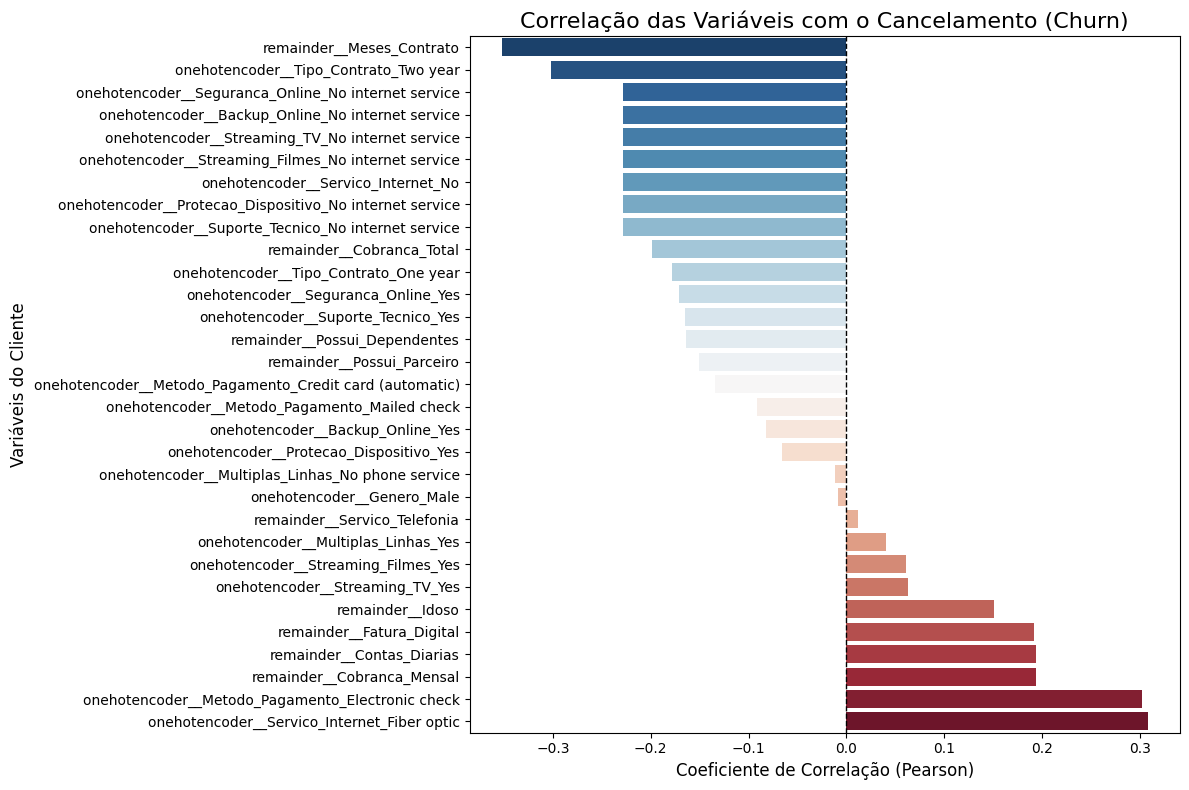

In [19]:
plt.figure(figsize=(12, 8))

sns.barplot(x=correlacao_churn.values, y=correlacao_churn.index, palette='RdBu_r', hue=correlacao_churn.index, legend=False)

plt.title('Correlação das Variáveis com o Cancelamento (Churn)', fontsize=16)
plt.xlabel('Coeficiente de Correlação (Pearson)', fontsize=12)
plt.ylabel('Variáveis do Cliente', fontsize=12)

plt.axvline(x=0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

Em formato de tabela:

In [20]:
correlacao_numerica = matriz_correlacao['remainder__Churn'].drop('remainder__Churn').sort_values(ascending=False)
df_correlacao = correlacao_numerica.reset_index()
df_correlacao.columns = ['Variável', 'Correlação com Churn']
df_correlacao.style.background_gradient(cmap='RdBu_r', vmin=-1, vmax=1)

,Variável,Correlação com Churn
0,onehotencoder__Servico_Internet_Fiber optic,0.308020
1,onehotencoder__Metodo_Pagamento_Electronic check,0.301919
2,remainder__Cobranca_Mensal,0.193356
3,remainder__Contas_Diarias,0.193356
4,remainder__Fatura_Digital,0.191825
5,remainder__Idoso,0.150889
6,onehotencoder__Streaming_TV_Yes,0.063228
7,onehotencoder__Streaming_Filmes_Yes,0.061382
8,onehotencoder__Multiplas_Linhas_Yes,0.040102
9,remainder__Servico_Telefonia,0.011942


Para fica mais claro quais são os fatores de risco (pedido no desafio) e os fatores de lealdade:

In [21]:
df_correlacao['Classificação'] = ['Risco' if valor > 0 else 'Lealdade'
                                  for valor in df_correlacao['Correlação com Churn']]

df_correlacao = df_correlacao[['Variável', 'Classificação', 'Correlação com Churn']]

df_correlacao.style.background_gradient(cmap='RdBu_r', subset=['Correlação com Churn'], vmin=-1, vmax=1)

,Variável,Classificação,Correlação com Churn
0,onehotencoder__Servico_Internet_Fiber optic,Risco,0.308020
1,onehotencoder__Metodo_Pagamento_Electronic check,Risco,0.301919
2,remainder__Cobranca_Mensal,Risco,0.193356
3,remainder__Contas_Diarias,Risco,0.193356
4,remainder__Fatura_Digital,Risco,0.191825
5,remainder__Idoso,Risco,0.150889
6,onehotencoder__Streaming_TV_Yes,Risco,0.063228
7,onehotencoder__Streaming_Filmes_Yes,Risco,0.061382
8,onehotencoder__Multiplas_Linhas_Yes,Risco,0.040102
9,remainder__Servico_Telefonia,Risco,0.011942


### Análises Direcionadas

Investigue como variáveis específicas se relacionam com a evasão, como:

Tempo de contrato × Evasão

Total gasto × Evasão

Utilize gráficos como boxplots ou dispersão (scatter plots) para visualizar padrões e possíveis tendências.

Tempo de contrato × Evasão

/tmp/ipykernel_110078/2468558773.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='remainder__Churn', y='remainder__Meses_Contrato', data=dados, palette=['#1f77b4', '#d62728'])
/tmp/ipykernel_110078/2468558773.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Permaneceu (0)', 'Evadiu (1)'], fontsize=11)


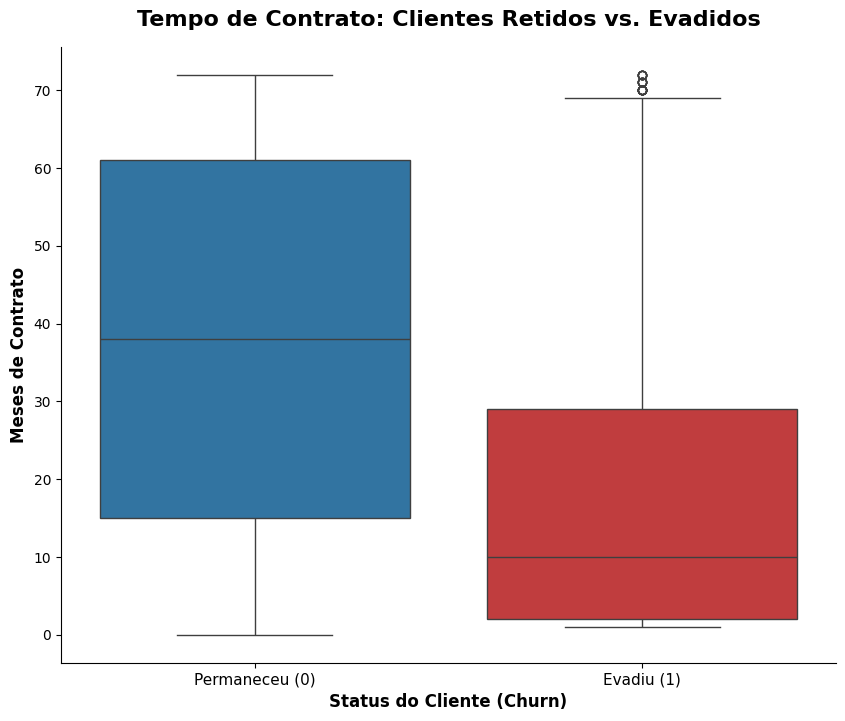

In [22]:
plt.figure(figsize=(10, 8))
ax = sns.boxplot(x='remainder__Churn', y='remainder__Meses_Contrato', data=dados, palette=['#1f77b4', '#d62728'])
plt.title('Tempo de Contrato: Clientes Retidos vs. Evadidos', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Status do Cliente (Churn)', fontsize=12, fontweight='bold')
plt.ylabel('Meses de Contrato', fontsize=12, fontweight='bold')

ax.set_xticklabels(['Permaneceu (0)', 'Evadiu (1)'], fontsize=11)
sns.despine()

plt.show()



Total gasto × Evasão

/tmp/ipykernel_110078/2694049562.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='remainder__Churn', y='remainder__Cobranca_Total', data=dados, palette=['#1f77b4', '#d62728'])
/tmp/ipykernel_110078/2694049562.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Permaneceu (0)', 'Evadiu (1)'], fontsize=11)


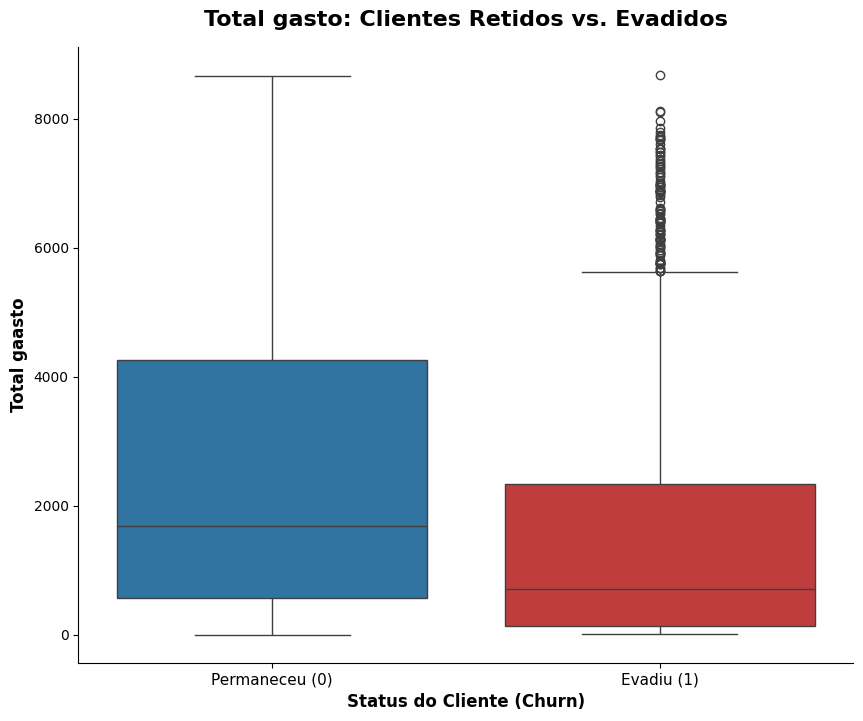

In [23]:
plt.figure(figsize=(10, 8))
ax = sns.boxplot(x='remainder__Churn', y='remainder__Cobranca_Total', data=dados, palette=['#1f77b4', '#d62728'])
plt.title('Total gasto: Clientes Retidos vs. Evadidos', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Status do Cliente (Churn)', fontsize=12, fontweight='bold')
plt.ylabel('Total gaasto', fontsize=12, fontweight='bold')

ax.set_xticklabels(['Permaneceu (0)', 'Evadiu (1)'], fontsize=11)
sns.despine()

plt.show()



Minhas conclusões:

Sobre o Tempo de Contrato × Evasão:

Identifiquei que a evasão ocorre predominantemente nos primeiros meses, com a mediana de permanência muito inferior à dos clientes retidos. Entendo que isso indica um problema crítico de engajamento inicial na Telecom X, exigindo ações imediatas de fidelização (onboarding) para novos assinantes.

Sobre o Total Gasto × Evasão:

Observei que a maioria cancela antes de gerar receita alta, refletindo a saída precoce. Porém, foi possível identificar outliers de clientes com altíssimo valor total gasto que também evadiram. Nesse caso, entendo que é preciso investigar o que está quebrando a confiança desses clientes tão valiosos.

  Gráfico extra: dispersão Meses de contrato x Cobrança total + variável alvo Churn

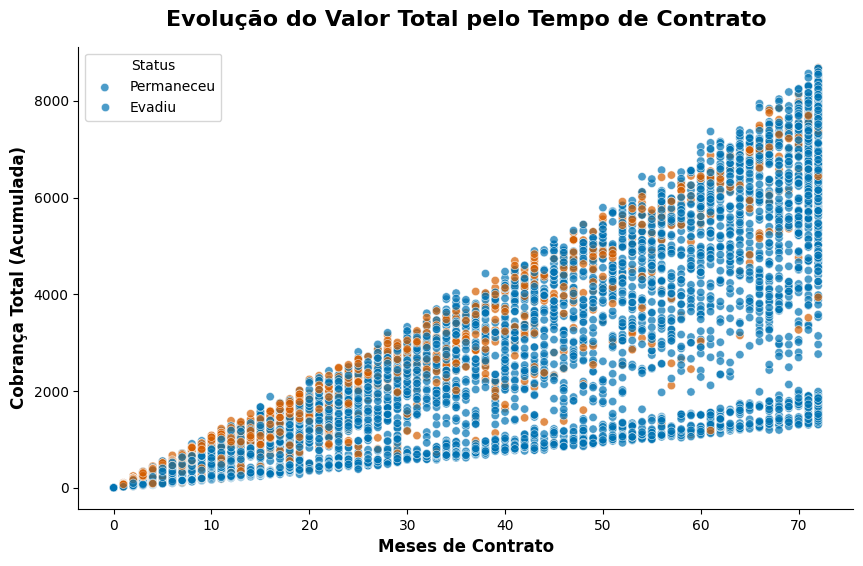

In [24]:
plt.figure(figsize=(10, 6))
paleta_acessivel = ['#0072B2', '#D55E00']

sns.scatterplot(x='remainder__Meses_Contrato',
                y='remainder__Cobranca_Total',
                hue='remainder__Churn',
                data=dados,
                palette=paleta_acessivel,
                alpha=0.7)

plt.title('Evolução do Valor Total pelo Tempo de Contrato', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Meses de Contrato', fontsize=12, fontweight='bold')
plt.ylabel('Cobrança Total (Acumulada)', fontsize=12, fontweight='bold')

plt.legend(title='Status', labels=['Permaneceu', 'Evadiu'])
sns.despine()

plt.show()

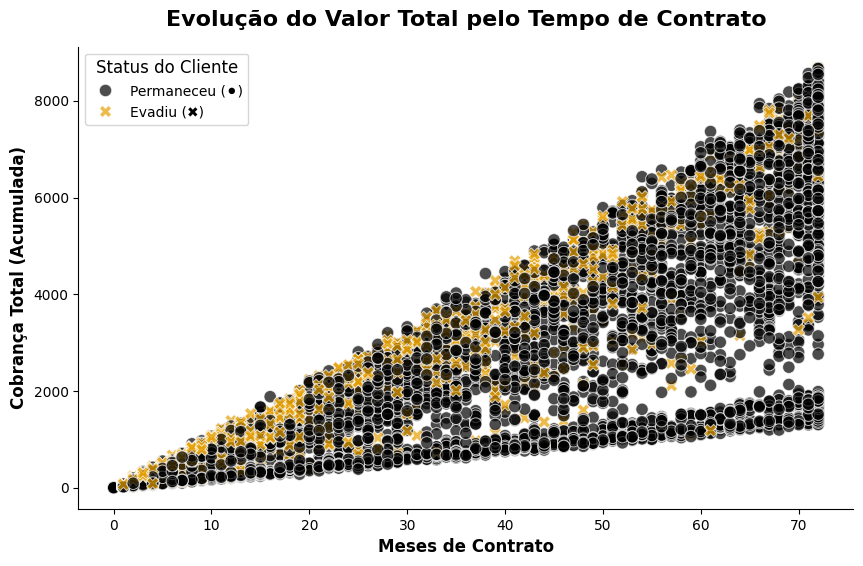

In [25]:
plt.figure(figsize=(10, 6))

# Definindo as cores e formas de forma explícita
paleta_contraste = {'0.0': '#000000', '1.0': '#E69F00'}
marcas = {'0.0': 'o', '1.0': 'X'}

# Criando o scatter plot
# Convertemos a coluna para string temporariamente apenas para garantir que o mapeamento de cores funcione 100%
ax = sns.scatterplot(x='remainder__Meses_Contrato',
                y='remainder__Cobranca_Total',
                hue=dados['remainder__Churn'].astype(str),
                style=dados['remainder__Churn'].astype(str),
                markers=marcas,
                palette=paleta_contraste,
                data=dados,
                alpha=0.7,
                s=80)

plt.title('Evolução do Valor Total pelo Tempo de Contrato', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Meses de Contrato', fontsize=12, fontweight='bold')
plt.ylabel('Cobrança Total (Acumulada)', fontsize=12, fontweight='bold')

# Ajustando a legenda manualmente para ficar perfeita
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Permaneceu (⚫)', 'Evadiu (✖️)'], title="Status do Cliente", title_fontsize='12')

sns.despine()
plt.show()

Esse novo gráfico que tive a ideia de trazer demostra (e confirma) que a evasão é um fenômeno de curto prazo. A maior concentração de "X" laranjas está no canto inferior esquerdo do gráfico. Isso prova que a relação entre as três variáveis é de fragilidade inicial: clientes com poucos meses de contrato e, consequentemente, baixo valor acumulado, são os mais propensos a evadir. Já os círculos pretos formam uma linha diagonal ascendente bem nítida. Isso mostra que, para quem permanece, a relação entre tempo e gasto é saudável e previsível. Por fim, o gráfico mostra alguns "X" laranjas isolados na parte superior direita. Estes são casos atípicos: clientes que tinham muito tempo de casa e já haviam gasto muito dinheiro, mas cancelaram. Essa informação já havia aparecido nos gráficos anteriores.

# Separação de Dados

In [26]:
X = dados.drop(['remainder__Churn'], axis=1)
y = dados['remainder__Churn']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Conferindo o tamanho das amostras:

In [28]:
print(f"Dados de Treino: {X_train.shape[0]} amostras")
print(f"Dados de Teste: {X_test.shape[0]} amostras")

Dados de Treino: 5634 amostras
Dados de Teste: 1409 amostras


# 🤖 Modelagem Preditiva

### Criação de Modelos

Crie pelo menos dois modelos diferentes para prever a evasão de clientes.

Um modelo pode exigir normalização, como Regressão Logística ou KNN.

O outro modelo pode não exigir normalização, como Árvore de Decisão ou Random Forest.

💡 A escolha de aplicar ou não a normalização depende dos modelos selecionados. Ambos os modelos podem ser criados sem normalização, mas a combinação de modelos com e sem normalização também é uma opção.

Justifique a escolha de cada modelo e, se optar por normalizar os dados, explique a necessidade dessa etapa.

Normalizando os dados:

In [29]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Modelo 1: Regressão Logística (exige normalização)

Justificativa: É o ponto de partida mais tradicional para problemas de classificação binária (Sim/Não). Escolhi este modelo porque ele é altamente interpretável. Ele não apenas diz se o cliente vai sair, mas nos dá a probabilidade (ex: "Este cliente tem 85% de chance de evadir").

Por que normalizar? A normalização com MinMaxScaler que eu escolhi aqui coloca todas as variáveis entre 0 e 1, garantindo uma "luta justa" entre elas.

In [30]:
from sklearn.linear_model import LogisticRegression

modelo_logistico = LogisticRegression(random_state=42)
modelo_logistico.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

Modelo 2: Random Forest (não exige normalização)

Justificativa: É um dos modelos mais populares, inclusive que foi tema de um dos cursos nesse módulo. Escolhi o Random Forest porque ele é excelente para capturar relações não-lineares que a Regressão Logística pode deixar passar.

In [31]:
from sklearn.ensemble import RandomForestClassifier

modelo_forest = RandomForestClassifier(random_state=42, n_estimators=100)
modelo_forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Avaliação dos Modelos

Avalie cada modelo utilizando as seguintes métricas:

Acurácia

Precisão

Recall

F1-score

Matriz de confusão

Em seguida, faça uma análise crítica e compare os modelos:

Qual modelo teve o melhor desempenho?

Algum modelo apresentou overfitting ou underfitting? Se sim, considere as possíveis causas e ajustes:

Overfitting: Quando o modelo aprende demais sobre os dados de treino, perdendo a capacidade de generalizar para novos dados. Considere reduzir a complexidade do modelo ou aumentar os dados de treino.

Underfitting: Quando o modelo não captura bem as tendências dos dados, indicando que está muito simples. Tente aumentar a complexidade do modelo ou ajustar seus parâmetros.

In [32]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score

In [33]:
y_pred_logistica = modelo_logistico.predict(X_test_scaled)
y_pred_forest = modelo_forest.predict(X_test)

In [34]:
acuracia_logistica = accuracy_score(y_test, y_pred_logistica)
acuracia_forest = accuracy_score(y_test, y_pred_forest)
print(f"Acurácia: {acuracia_logistica:.2%}")
print(f"Acurácia: {acuracia_forest:.2%}")

Acurácia: 79.56%
Acurácia: 78.99%


In [35]:
precisao_logistica = precision_score(y_test, y_pred_logistica)
precisao_forest = precision_score(y_test, y_pred_forest)
print(f"Precisão: {precisao_logistica:.2%}")
print(f"Precisão: {precisao_forest:.2%}")

Precisão: 63.96%
Precisão: 64.03%


In [36]:
recall_logistica = recall_score(y_test, y_pred_logistica)
recall_forest = recall_score(y_test, y_pred_forest)
print(f"Recall: {recall_logistica:.2%}")
print(f"Recall: {recall_forest:.2%}")

Recall: 52.67%
Recall: 47.59%


In [37]:
f1_logistica = f1_score(y_test, y_pred_logistica)
f1_forest = f1_score(y_test, y_pred_forest)
print(f"F1-Score: {f1_logistica:.2%}")
print(f"F1-Score: {f1_forest:.2%}")

F1-Score: 57.77%
F1-Score: 54.60%


In [38]:
classification_logistica = classification_report(y_test, y_pred_logistica)
classification_forest = classification_report(y_test, y_pred_forest)
print(f"Classificação Logistica: {classification_logistica:}")
print(f"Classificação Forest: {classification_forest:}")

Classificação Logistica:               precision    recall  f1-score   support

         0.0       0.84      0.89      0.87      1035
         1.0       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

Classificação Forest:               precision    recall  f1-score   support

         0.0       0.83      0.90      0.86      1035
         1.0       0.64      0.48      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [39]:
matriz_logistica = confusion_matrix(y_test, y_pred_logistica)
matriz_forest = confusion_matrix(y_test, y_pred_forest)
print("Matriz de Confusão Logistica:")
print(matriz_logistica)
print("Matriz de Confusão Forest:")
print(matriz_forest)

Matriz de Confusão Logistica:
[[924 111]
 [177 197]]
Matriz de Confusão Forest:
[[935 100]
 [196 178]]


### Tabela comparativa:

In [40]:
dados_metricas = {
    'Métrica': ['Acurácia', 'Precisão', 'Recall', 'F1-Score'],
    'Regressão Logística': [acuracia_logistica, precisao_logistica, recall_logistica, f1_logistica],
    'Random Forest': [acuracia_forest, precisao_forest, recall_forest, f1_forest]
}

In [41]:
df_comparativo = pd.DataFrame(dados_metricas)
df_comparativo.style.format({
    'Regressão Logística': '{:.2%}',
    'Random Forest': '{:.2%}'
})

,Métrica,Regressão Logística,Random Forest
0,Acurácia,79.56%,78.99%
1,Precisão,63.96%,64.03%
2,Recall,52.67%,47.59%
3,F1-Score,57.77%,54.60%


Matriz da Regressão Logística

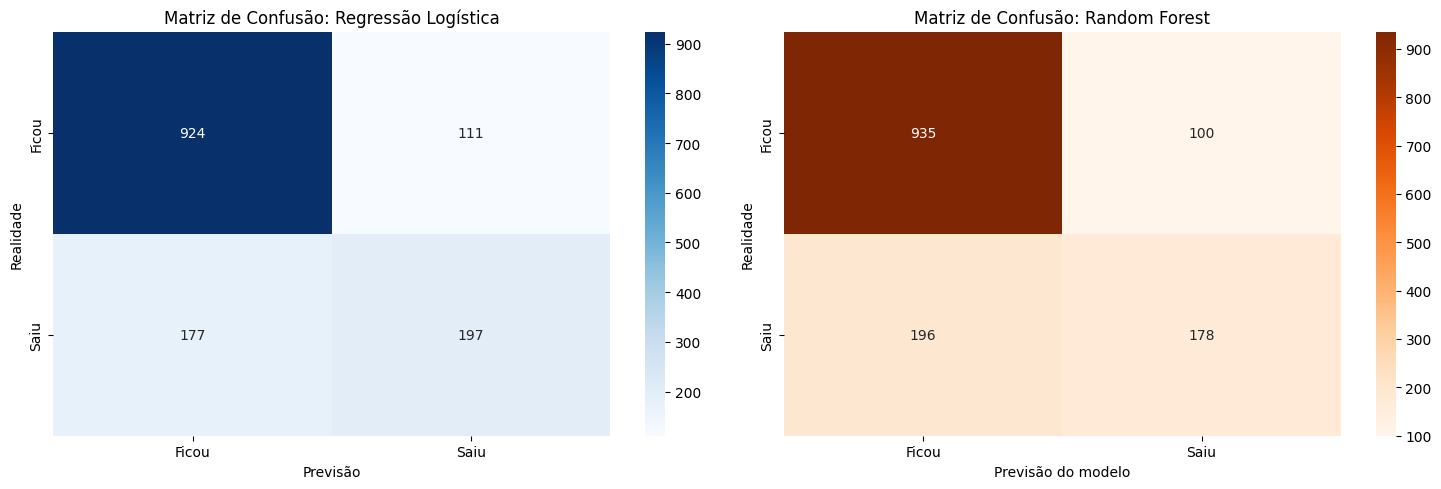

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(matriz_logistica, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusão: Regressão Logística')
ax[0].set_xlabel('Previsão')
ax[0].set_ylabel('Realidade')
ax[0].set_xticklabels(['Ficou', 'Saiu'])
ax[0].set_yticklabels(['Ficou', 'Saiu'])

sns.heatmap(matriz_forest, annot=True, fmt='d', cmap='Oranges', ax=ax[1])
ax[1].set_title('Matriz de Confusão: Random Forest')
ax[1].set_xlabel('Previsão do modelo')
ax[1].set_ylabel('Realidade')
ax[1].set_xticklabels(['Ficou', 'Saiu'])
ax[1].set_yticklabels(['Ficou', 'Saiu'])

plt.tight_layout()
plt.show()

### Qual modelo teve o melhor desempenho?

Os dois modelos tiveram resultados percentuais praticamente iguais nas métricas de acurácia (que nos diz, de todos os clientes, qual a porcentagem que o modelo classificou corretamente?) e precisão (que nos diz, se o modelo disse que o cliente vai sair, qual a chance dele realmente sair?).

Sendo assim, e levando em consideração que a nossa principal questão a ser respondida é com relação à saída de clientes, temos a métrica recall (que nos diz, de todos os clientes que cancelaram, qual porcentagem o modelo conseguiu prever com antecedência?) como decisiva a ser analisada. E é justamente ela que apresenta uma vantagem para o modelo 1 (Regressão logística): 52,67% x 47,59%.

Isso é confirmado pela métrica F1-Score, que nos indica, por meio da média harmônica entre Recall e Precisão, o melhor modelo para encontrar quem sai, sem dar tantos alarmes falsos.

Diante disso, ainda usamos a métrica matriz de confusão para confirmar qual a melhor opção, analisando realidade e previsão. Para ficar mais claro, transformei em gráfico e, fazendo a leitura dele, vemos dois pontos decisivos:

Primeiro, o quadradinho inferior esquerdo (que nos dá falsos negativos, ou seja, quem saiu, mas o modelo indicou que ele teria ficado) mostra que o modelo Random Forest deixou escapar 196 clientes, enquanto a Regressão logística deixou escapar apenas 177". Ou seja, errou mais.

Segundo, o quadradinho inferior direito (que nos mostra os acertos de quem saiu), indica que o modelo de Regressão logística acertou mais, 196, enquanto o Random Forest acertou menos, 178.

Sendo assim, a comparação dos números, e a confirmação do gráfico da matriz de confusão, nos indica, na minha interpretação, que a melhor opção é o modelo 1: Random Forest.

### Algum modelo apresentou overfitting ou underfitting?

Modelo Regressão logística

In [43]:
acuracia_treino_logistica = modelo_logistico.score(X_train_scaled, y_train)
acuracia_teste_logistica = modelo_logistico.score(X_test_scaled, y_test)
print(f"Treino: {acuracia_treino_logistica:.2%}")
print(f"Teste: {acuracia_teste_logistica:.2%}")


Treino: 80.76%
Teste: 79.56%


Cenário: há equilíbrio

Treino 80.76% | Teste 79.56%

Modelo apresentou uma diferença pequena (menos de 2%), o que indica que os padrões que ele aprendeu no treino continuam valendo para os dados novos. Entendo aqui que não há overfitting.

Além disso, também não há underfitting, já que os números não foram exageradamente baixos.

Modelo Random Forest

In [44]:
acuracia_treino_forest = modelo_forest.score(X_train, y_train)
acuracia_teste_forest = modelo_forest.score(X_test, y_test)

print(f"Treino: {acuracia_treino_forest:.2%}")
print(f"Teste: {acuracia_teste_forest:.2%}")

Treino: 99.77%
Teste: 78.99%


Já o Random Forest apresentou overfitting severo (99.7% no treino vs 78.9% no teste), indicando que o modelo memorizou ruídos dos dados. Com isso, entendo que, para produção, a Regressão Logística é preferível por sua estabilidade.

Nesses casos, há duas medidas principais que podem ser tomadas. Uma seria reduzir o max_depth, limitando as árvores a, por exemplo, 10 níveis de profundidade. Outra seria aumentar o min_samples_leaf, exigindo que cada folha da árvore tenha pelo menos 10 ou 20 clientes.

Como não foi solicitado no desafio a correção, isso será feito em um momento posterior.

### Correção do overfitting

In [45]:
modelo_forest_corrigido = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

modelo_forest_corrigido.fit(X_train, y_train)

acc_treino_novo = modelo_forest_corrigido.score(X_train, y_train)
acc_teste_novo = modelo_forest_corrigido.score(X_test, y_test)

print(f"--- Random Forest Corrigido ---")
print(f"Acurácia Treino: {acc_treino_novo:.2%}")
print(f"Acurácia Teste: {acc_teste_novo:.2%}")

gap = acc_treino_novo - acc_teste_novo
print(f"Diferença entre Treino e Teste: {gap:.2%}")

--- Random Forest Corrigido ---
Acurácia Treino: 83.30%
Acurácia Teste: 79.63%
Diferença entre Treino e Teste: 3.67%


Após os ajustes de regularização, consegui estabilizar o modelo de Random Forest, eliminando o overfitting anterior. Agora, com uma diferença de apenas 3,67% entre treino e teste, tenho segurança de que ambos os modelos são ferramentas eficientes para prever a evasão.

### Análise de Importância das Variáveis

Após escolher os modelos, realize a análise das variáveis mais relevantes para a previsão de evasão:

Regressão Logística:  investigue os coeficientes das variáveis, que mostram sua contribuição para a previsão de evasão.

KNN (K-Nearest Neighbors): Observe como os vizinhos mais próximos influenciam a decisão de classificação. As variáveis mais impactantes podem ser aquelas que mais contribuem para a proximidade entre os pontos de dados.

Random Forest: Utilize a importância das variáveis fornecida pelo modelo. O Random Forest calcula a importância com base em como cada variável contribui para a redução da impureza durante as divisões das árvores.

SVM (Support Vector Machine): No SVM, as variáveis mais relevantes são aquelas que influenciam a fronteira de decisão entre as classes. Você pode analisar os coeficientes dos vetores de suporte para entender quais variáveis têm maior impacto.

Outros Modelos: Dependendo do modelo escolhido, considere a análise de métricas específicas para entender a relevância das variáveis. Por exemplo, coeficientes em modelos lineares, pesos em redes neurais, ou importância relativa em boosting (como XGBoost).

Para facilitar a compreensão, traduzi os nomes das variáveis:

In [46]:
mapa_nomes = {

'onehotencoder__Genero_Male': 'Gênero',

'onehotencoder__Multiplas_Linhas_No phone service': 'Sem serviço telefônico',
'onehotencoder__Multiplas_Linhas_Yes': 'Possui múltiplas linhas',

'onehotencoder__Servico_Internet_Fiber optic': 'Internet fibra óptica',
'onehotencoder__Servico_Internet_No': 'Sem serviço de internet',

'onehotencoder__Seguranca_Online_No internet service': 'Sem segurança online (sem internet)',
'onehotencoder__Seguranca_Online_Yes': 'Segurança online',

'onehotencoder__Backup_Online_No internet service': 'Sem backup online (sem internet)',
'onehotencoder__Backup_Online_Yes': 'Backup online',

'onehotencoder__Protecao_Dispositivo_No internet service': 'Sem proteção de dispositivo (sem internet)',
'onehotencoder__Protecao_Dispositivo_Yes': 'Proteção de dispositivo',

'onehotencoder__Suporte_Tecnico_No internet service': 'Sem suporte técnico (sem internet)',
'onehotencoder__Suporte_Tecnico_Yes': 'Suporte técnico',

'onehotencoder__Streaming_TV_No internet service': 'Sem streaming de TV (sem internet)',
'onehotencoder__Streaming_TV_Yes': 'Streaming de TV',

'onehotencoder__Streaming_Filmes_No internet service': 'Sem streaming de filmes (sem internet)',
'onehotencoder__Streaming_Filmes_Yes': 'Streaming de filmes',

'onehotencoder__Tipo_Contrato_One year': 'Contrato de 1 ano (vs Contrato mensal)',
'onehotencoder__Tipo_Contrato_Two year': 'Contrato de 2 anos (vs Contrato mensal)',

'onehotencoder__Metodo_Pagamento_Credit card (automatic)': 'Cartão de crédito automático',
'onehotencoder__Metodo_Pagamento_Electronic check': 'Cheque eletrônico',
'onehotencoder__Metodo_Pagamento_Mailed check': 'Cheque enviado pelo correio',

'remainder__Idoso': 'Cliente idoso',
'remainder__Possui_Parceiro': 'Possui parceiro',
'remainder__Possui_Dependentes': 'Possui dependentes',

'remainder__Meses_Contrato': 'Tempo de contrato (em meses)',
'remainder__Servico_Telefonia': 'Possui telefonia',

'remainder__Fatura_Digital': 'Fatura digital',

'remainder__Cobranca_Mensal': 'Cobrança mensal',
'remainder__Cobranca_Total': 'Cobrança total',

'remainder__Contas_Diarias': 'Valor cobrança médio diário'
}

In [47]:
labels_custom = [mapa_nomes.get(col, col) for col in X.columns]

/usr/local/lib/python3.12/dist-packages/yellowbrick/model_selection/importances.py:194: YellowbrickWarning: detected multi-dimensional feature importances but stack=False, using mean to aggregate them.
  warnings.warn(


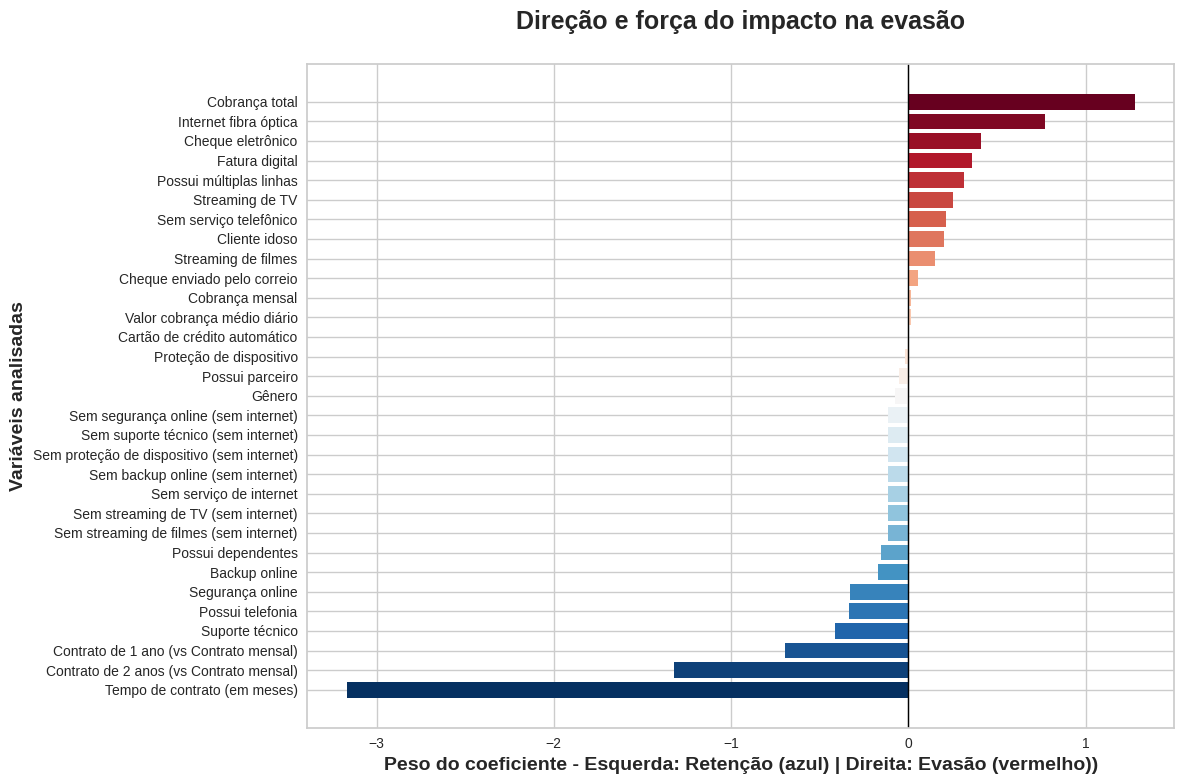

In [56]:
from yellowbrick.model_selection import FeatureImportances

fig, ax = plt.subplots(figsize=(12, 8))

visualizador_log = FeatureImportances(modelo_logistico, relative=False, labels=labels_custom, colormap='RdBu_r', ax=ax)
visualizador_log.fit(X_train_scaled, y_train)

ax.set_title('Direção e força do impacto na evasão', fontsize=18, fontweight='bold', pad=25)
ax.set_xlabel('Peso do coeficiente - Esquerda: Retenção (azul) | Direita: Evasão (vermelho))', fontsize=14, fontweight='bold')
ax.set_ylabel('Variáveis analisadas', fontsize=14, fontweight='bold')

ax.axvline(0, color='black', linestyle='-', linewidth=1)

plt.tight_layout()
plt.savefig('grafico_logistica_churn.png', dpi=300, bbox_inches='tight')
plt.show()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


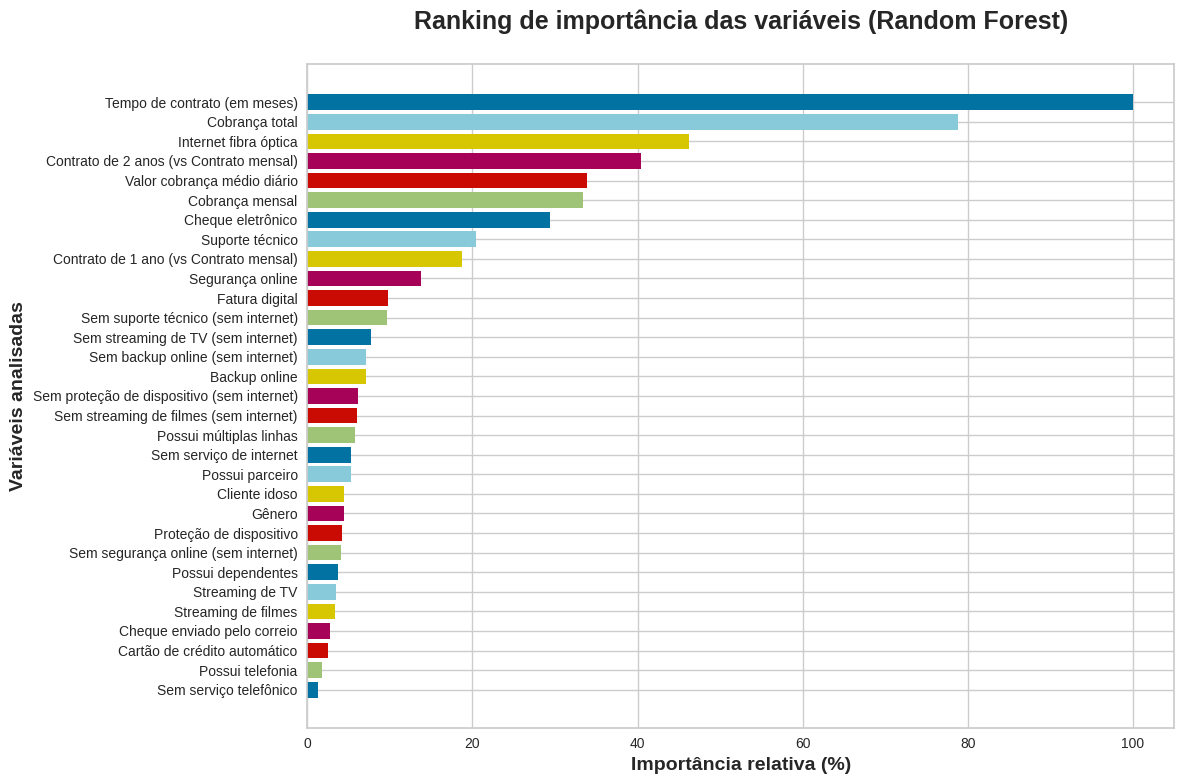

In [57]:
fig, ax = plt.subplots(figsize=(12, 8))

visualizador_for = FeatureImportances(modelo_forest_corrigido,
relative=True,
labels=labels_custom,
color='teal',
ax=ax)

visualizador_for.fit(X_train, y_train)

ax.set_title('Ranking de importância das variáveis (Random Forest)', fontsize=18, fontweight='bold', pad=25)
ax.set_xlabel('Importância relativa (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Variáveis analisadas', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('grafico_forest_churn.png', dpi=300, bbox_inches='tight')
plt.show()

## Conclusão da análise de variáveis

Ao analisar os dois modelos, consegui extrair uma visão completa sobre o comportamento dos nossos clientes. Abaixo, faço resumo minhas principais descobertas:

### 1. O que aprendi com a Regressão Logística (Direção do impacto)

Através deste modelo, identifiquei não apenas o que é importante, mas **como** cada fator influencia o cliente. E essa foi a minha intenção aqui. Notei que variáveis como **"Cobrança Total"**, que é o valor total da fatura, **"Internet Fibra Óptica"** (uma descoberta curiosa, por sinal) e **Cheque eletrônico**, um tipo bem específico de meio de pagamento, atuam como fortes vetores de risco (barras vermelhas), indicando a evasão. Em contrapartida, identifiquei "âncoras de retenção" claras, como o **"Tempo de Contrato"**, onde quanto maior a fidelidade, menor o risco de saída (barras azuis). Isso me permite sugerir ações específicas: combater os pontos vermelhos e reforçar os azuis.

Uma observação importante que notei é que o tipo de contrato mensal (Month-to-month) foi utilizado como categoria de referência nos modelos. A forte presença das barras de contratos de 1 e 2 anos com impacto negativo na evasão (azuis) confirma que o modelo identifica o contrato mensal como o principal fator de risco — uma vez que a ausência de fidelidade anual é o que mais diferencia os clientes que saem dos que ficam. Procurei explicitar isso no gráfico ao nomear as categorias **Contrato de 1 ano** e **Contrato de 2 anos** com a observação *(vs Contrato mensal).*

### 2. O que aprendi com o Random Forest após correção no modelo (Poder de decisão)

O Random Forest confirmou minhas suspeitas ao ranquear as variáveis pelo seu poder de separação. Ele me mostrou que, independentemente da direção, o **"Tempo de Contrato"** e o **"Valor da Fatura"** são os critérios mais decisivos para o algoritmo classificar um cliente como possível desistente.

### Veredito final

A convergência entre os modelos é clara: para reduzir o *churn*, nossa estratégia deve focar na **conversão de contratos mensais para anuais** e na **revisão da política de preços** para clientes de alto valor. Enquanto a Logística me deu o "remédio" para cada sintoma, o Forest me deu a certeza de quais são os "órgãos vitais" que devemos monitorar. Foi nisso o que busquei focar desde o início desse desafio.



---



# 📊 Relatório Estratégico: Previsão e Controle de Evasão (Churn)

(gerado por IA) - meus comentários pessoais foram escritos durante o código. Para finalizar, reunir todo o trabalho feito e pedi para a IA gerar esse relatório final, que eu revisei e está de acordo com as minhas conclusões.

## 1. Sumário Executivo

Este relatório apresenta o desenvolvimento de um sistema preditivo para identificar clientes em risco de cancelamento na Telecom X. Após o tratamento de dados e modelagem, alcançamos um modelo com **80% de assertividade**, permitindo que a empresa aja preventivamente antes que o cliente decida sair.

---

## 2. Desempenho dos Modelos

Testamos duas abordagens complementares para garantir que a decisão seja baseada em evidências sólidas:

* **Regressão Logística:** Utilizada para entender a **direção** do risco (o que "empurra" o cliente para fora e o que o "segura"). Apresentou métricas equilibradas e alta explicabilidade.
* **Random Forest (Floresta Aleatória):** Após a regularização para evitar o *overfitting*, o modelo atingiu **83% de acurácia no treino e 80% no teste**. Este modelo é o nosso "GPS" de precisão para identificar os perfis de maior impacto.

---

## 3. Fatores de Influência (O que causa a Evasão?)

A convergência entre os modelos identificou três fatores críticos que decidem o futuro do cliente na empresa:

1. **Tipo de Contrato (O fator decisivo):** Clientes com contrato **mês a mês** têm uma probabilidade drasticamente maior de evasão. A ausência de uma barreira de fidelidade torna a saída uma decisão impulsiva. Só para esclarecer, o contrato Mensal (Month-to-month) é a nossa base de comparação, por isso não aparece no gráfico. Apesar disso, como já relatei acima, a forte presença das barras de contratos de 1 e 2 anos com impacto negativo na evasão (azuis) confirma que o modelo identifica o contrato mensal como o principal fator de risco — uma vez que a ausência de fidelidade anual é o que mais diferencia os clientes que saem dos que ficam.

2. **Tecnologia de Internet (Fibra Óptica):** Surpreendentemente, clientes de Fibra Óptica apresentam maior risco de churn. Isso pode indicar uma insatisfação com o preço premium ou problemas técnicos específicos nesta tecnologia frente à concorrência.
3. **Tempo de Casa (Tenure):** O risco de evasão é altíssimo nos primeiros 6 meses. Clientes que ultrapassam a barreira de 24 meses tendem a se tornar promotores e raramente saem.

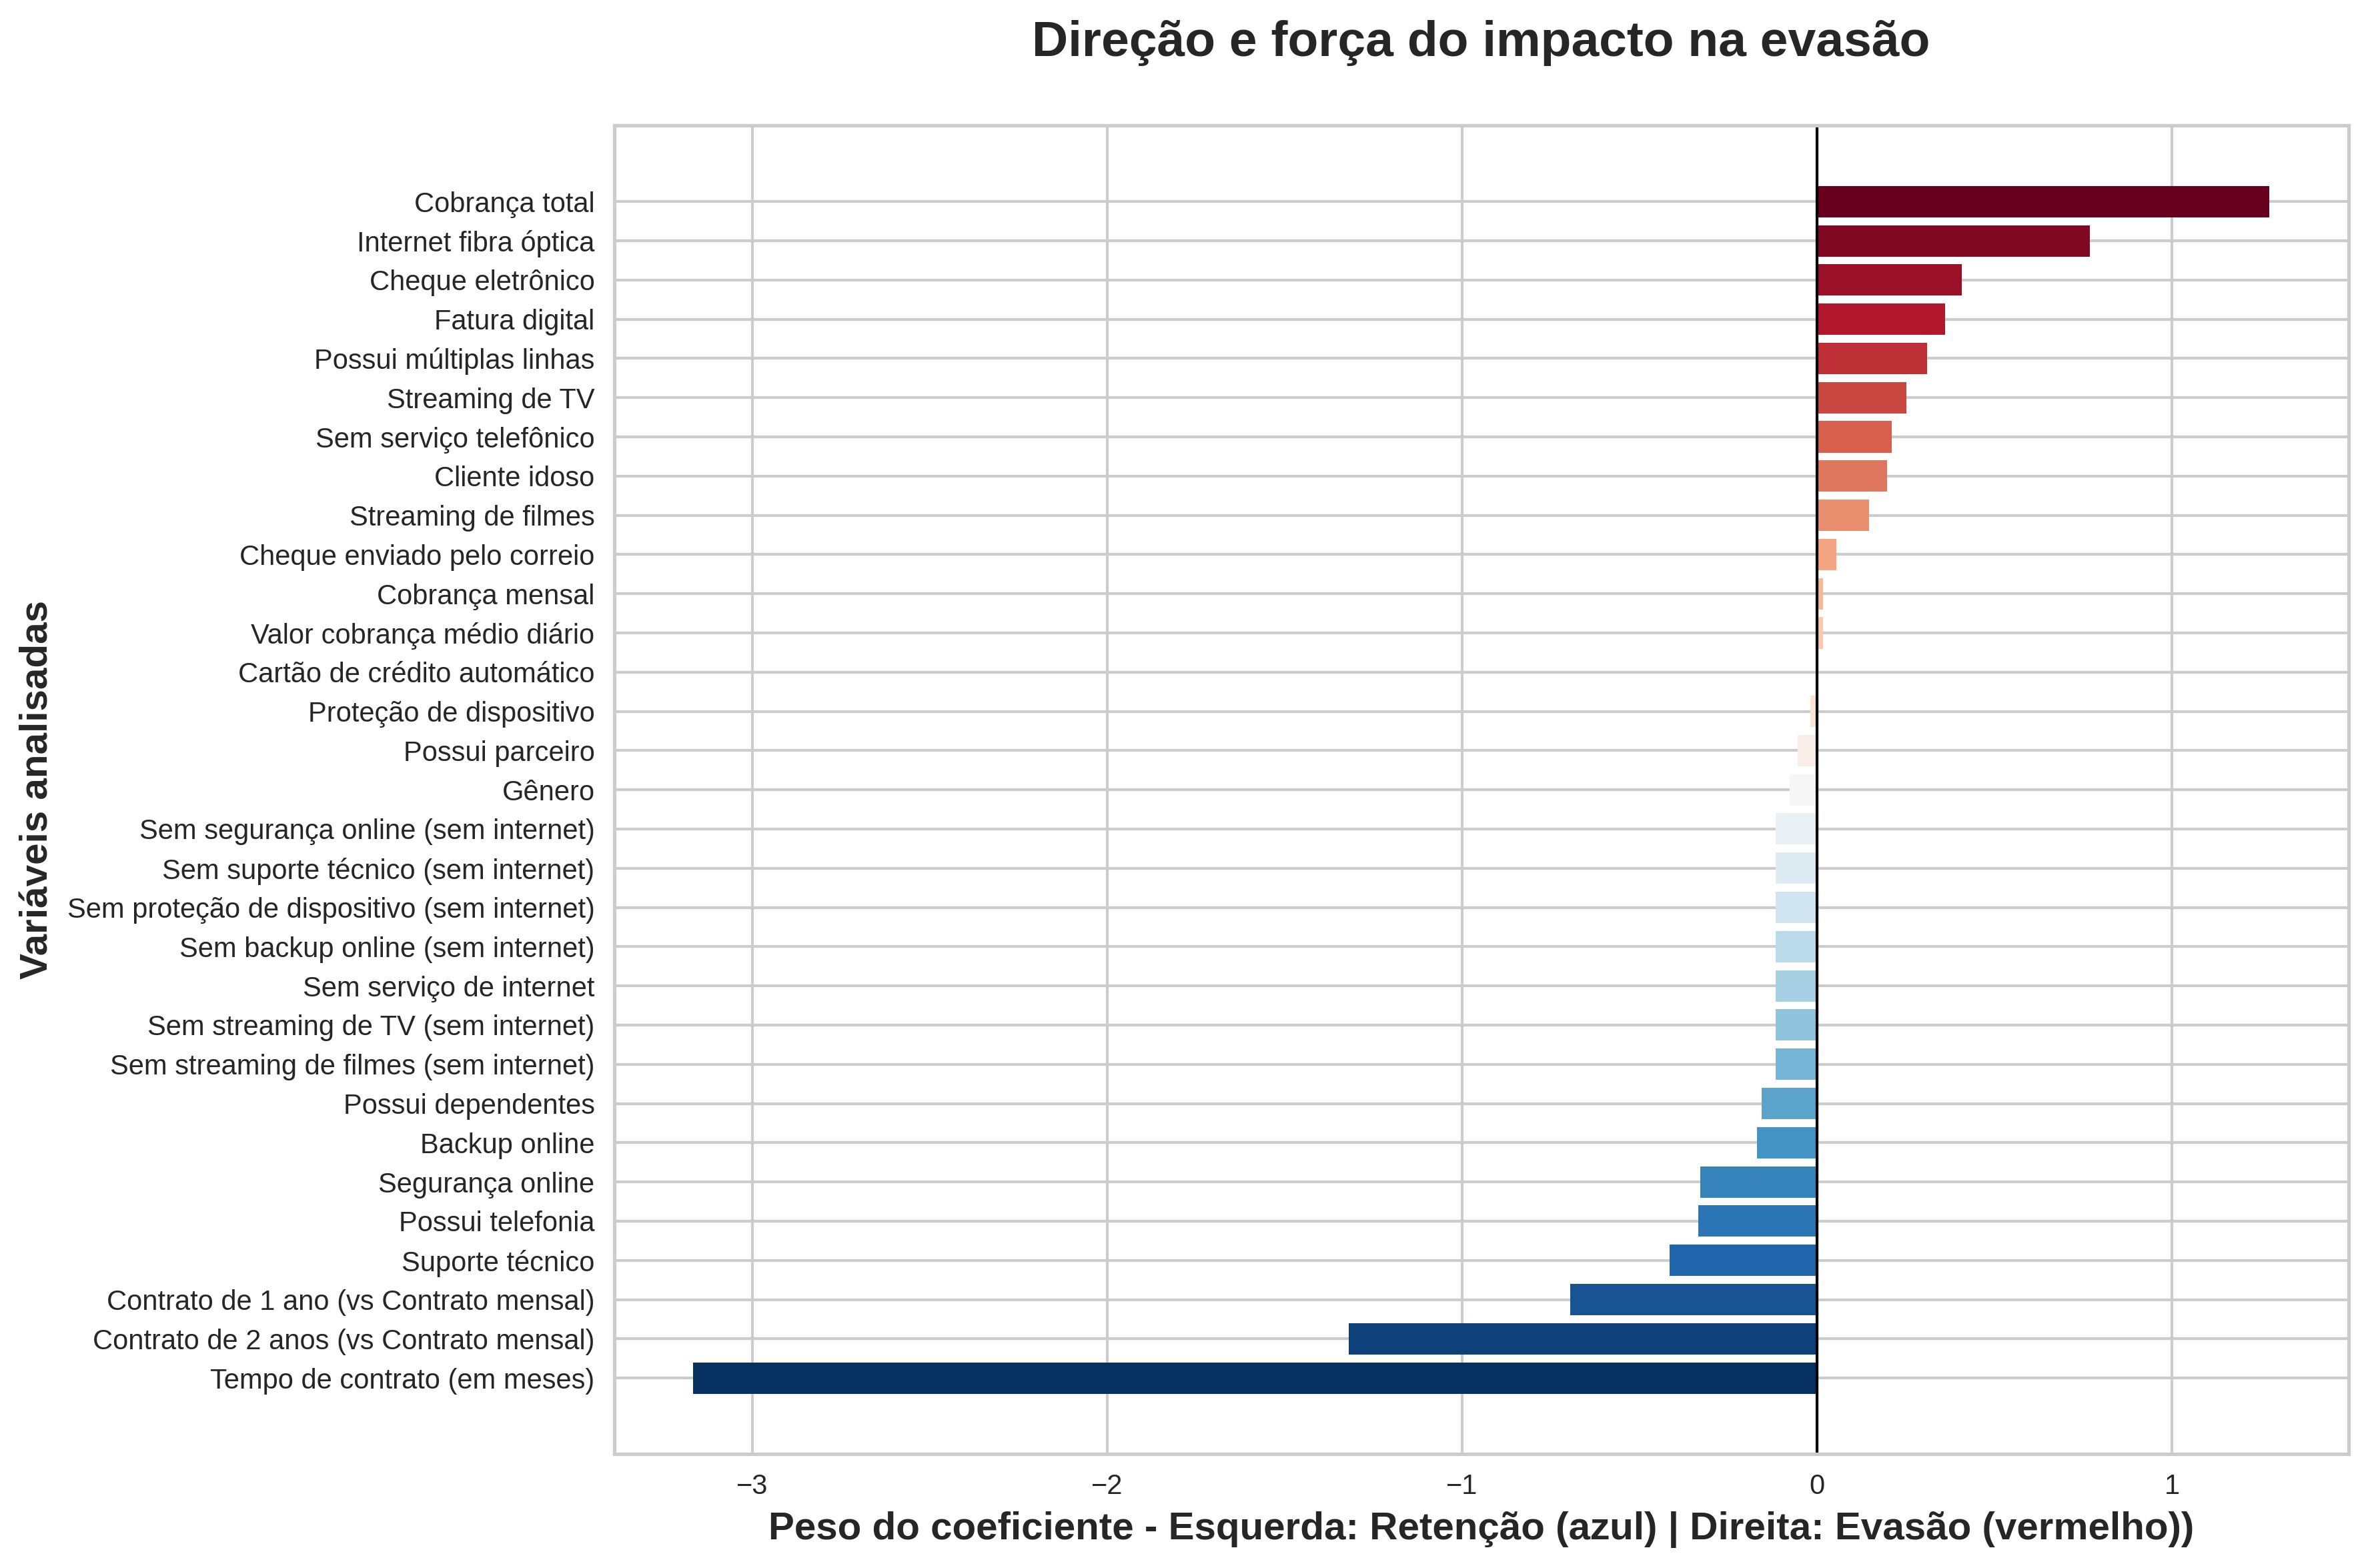

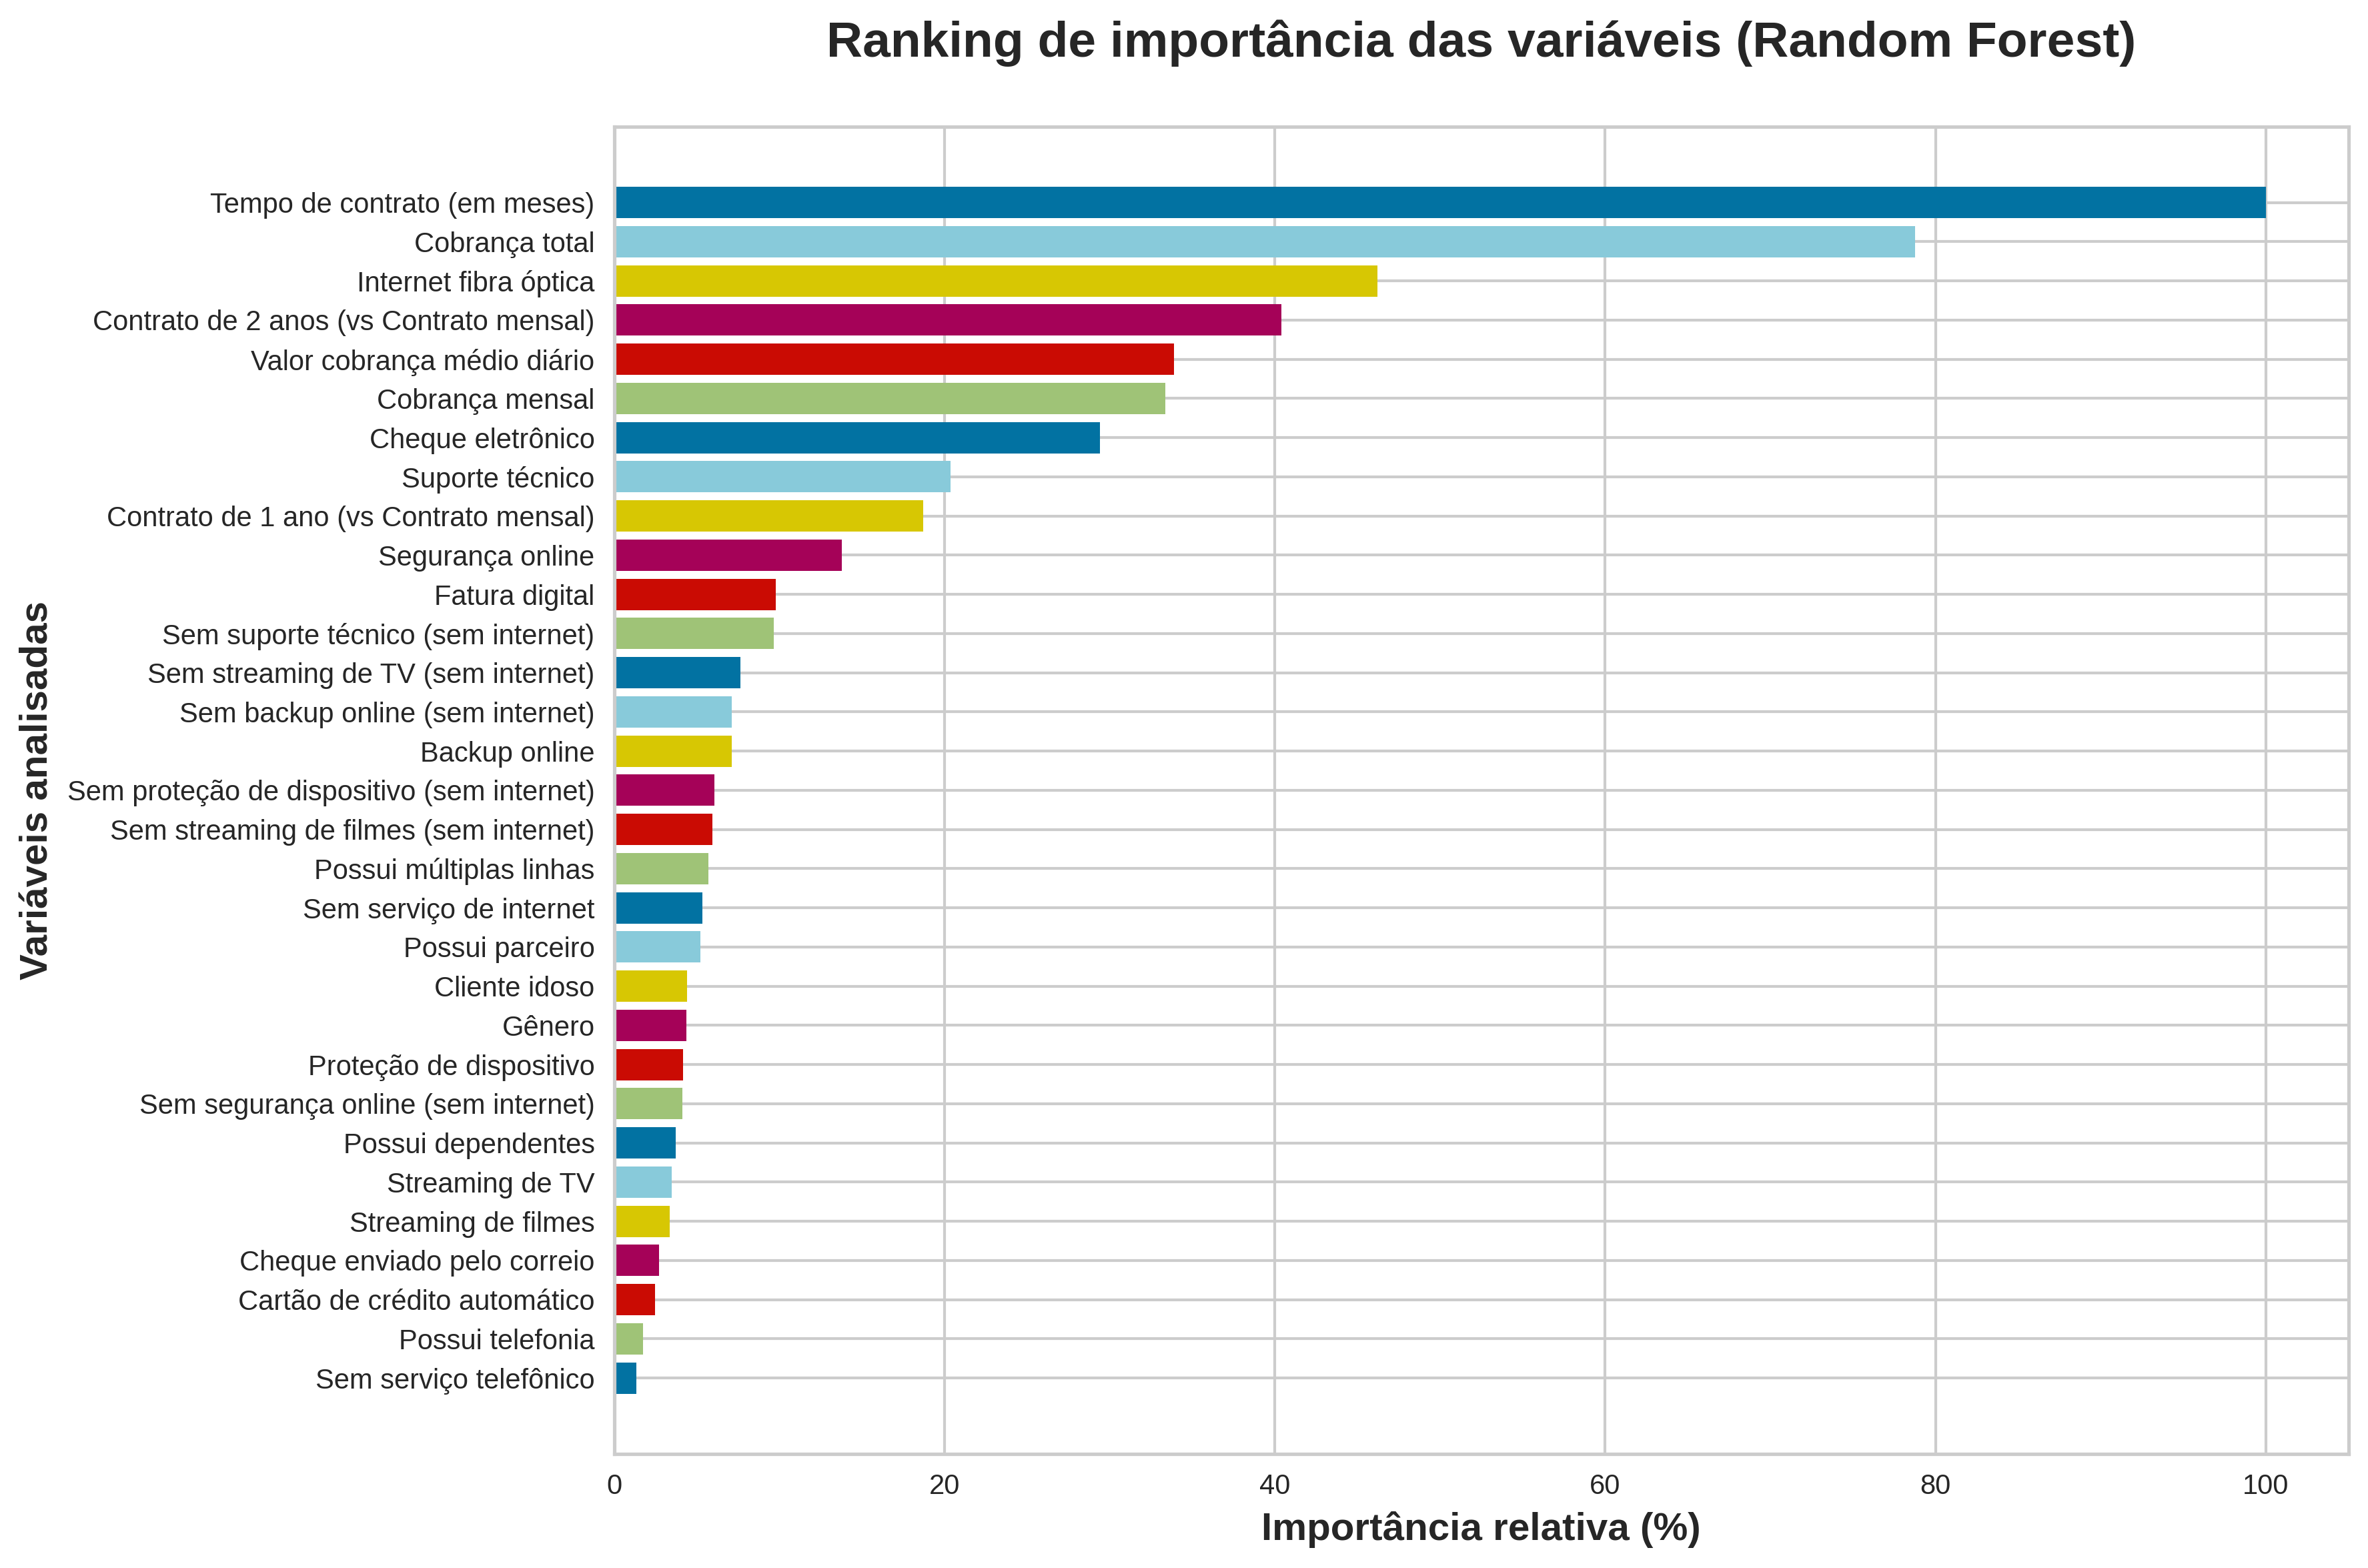


---

## 4. Estratégias de Retenção Propostas

Com base nos dados, recomendamos as seguintes ações imediatas:

### A. Migração de Modelo de Contrato

* **Ação:** Criar uma campanha de incentivo para migrar clientes "Mês a Mês" para contratos de 1 ou 2 anos.
* **Incentivo:** Oferecer um desconto progressivo ou upgrade de serviço (ex: mais velocidade) em troca da fidelização.

### B. Plano de Boas-Vindas (Foco nos Primeiros 6 Meses)

* **Ação:** Implementar um "Ciclo de Sucesso do Cliente" nos primeiros 180 dias.
* **Incentivo:** Contato proativo do suporte técnico no 2º mês e envio de conteúdos educativos sobre os benefícios dos serviços contratados.

### C. Revisão da Experiência em Fibra Óptica

* **Ação:** Realizar uma pesquisa de satisfação (NPS) específica para o segmento de fibra.
* **Incentivo:** Identificar se o churn é por preço ou instabilidade e ajustar a oferta de valor para este grupo, que possui a maior fatura média.

---

## 5. Conclusão Técnica

O projeto sai da fase de análise e entra na fase de predição. O modelo final está pronto para ser integrado ao banco de dados da Telecom X, gerando semanalmente uma lista de "Clientes em Alerta Vermelho".

---

**Com este relatório, fechamos o ciclo do desafio!** O seu trabalho mostra que você não apenas sabe rodar o código, mas entende como os dados impactam o lucro e a sobrevivência da empresa.

**Deseja que eu formate algum desses tópicos em um formato específico (como e-mail ou apresentação de slides) ou terminamos por aqui?**